In [3]:
from skimage import color, io, measure, img_as_ubyte
from skimage.measure import profile_line
from skimage.transform import rescale, resize
import matplotlib.pyplot as plt
import numpy as np
import pydicom as dicom
import sys
from skimage.filters import prewitt
from skimage.color import rgb2gray
from skimage.morphology import disk 

from skimage.morphology import erosion, dilation, opening, closing


In [4]:
#----Exercise1---- Reading an image

in_dir = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex1-IntroductionToImageAnalysis/data/"

im_name = "metacarpals.png"

im_org = io.imread(in_dir + im_name)






In [5]:
#----Exercise2---- Image Dimensions

print("Image dimensions: ", im_org.shape)


Image dimensions:  (512, 512)


In [6]:
#----Exercise3---- Check pixel type

print(im_org.dtype)


uint8


/tmp/ipykernel_40150/391408257.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org)
/tmp/ipykernel_40150/391408257.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


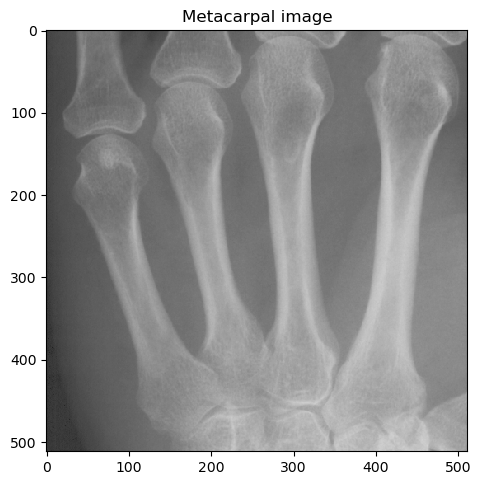

In [7]:
#----Exercise4---- Display the image

io.imshow(im_org)
plt.title("Metacarpal image")
io.show()

/tmp/ipykernel_40150/1327326447.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org, cmap="jet")
/tmp/ipykernel_40150/1327326447.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


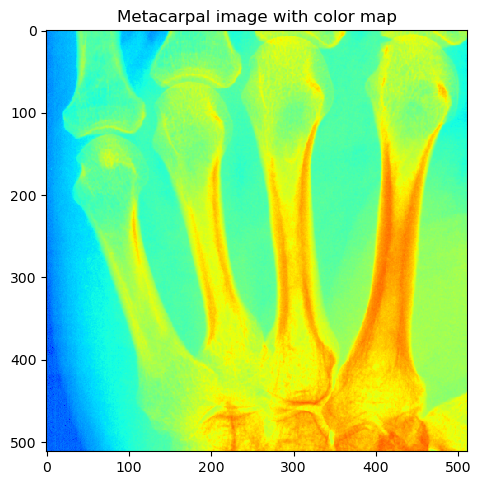

In [8]:
#----Exercise5---- Color Map
io.imshow(im_org, cmap="jet")
plt.title("Metacarpal image with color map")
io.show()


/tmp/ipykernel_40150/205624312.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(im_org, vmin=20,vmax=170)
/tmp/ipykernel_40150/205624312.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


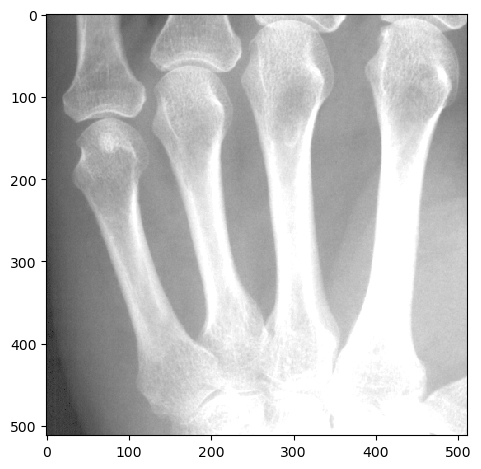

In [9]:
#----Exercise7--- Gray scale scaling
io.imshow(im_org, vmin=20,vmax=170)
plt.title("")
io.show()


There are 495.0 values in bin 50
Bin edges: 66.375 to the 67.0625


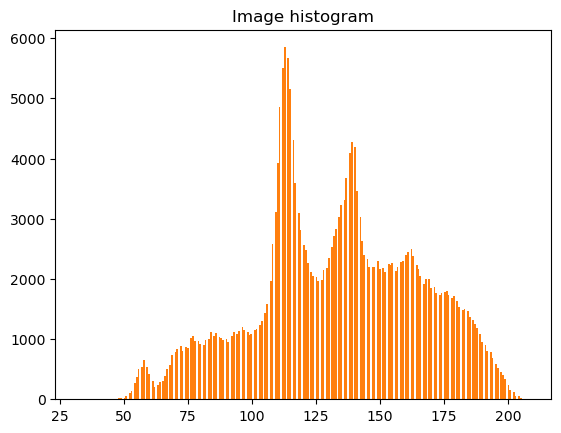

In [10]:
#----Exercise8--- Computing and visualizing the histogram of an image

plt.hist(im_org.ravel(),bins=256) # Ravel converts the image into a 1D array
plt.title("Image histogram")
# io.show()

h = plt.hist(im_org.ravel(),bins=256) # h is a list of tuples, where the first element is the bin count
                                      # and the second is the bin edge

bin_no = 50
count = h[0][bin_no]
print(f"There are {count} values in bin {bin_no}")

bin_left = h[1][bin_no]
bin_right = h[1][bin_no+1]
print(f"Bin edges: {bin_left} to the {bin_right}")


In [11]:

# #----Exercise9--- Using the histogram function to find the most common range of intensities
# max_number = 0
# # i = 0 
# # while i != len(h[0]):
# #     if max_number <= max(h[0][i]):
# #         max_number = max(h[0][i])
# #     i+=1 
print(len(h[0]))
peaks = []
bin_no = h[0]
for n in range(len(bin_no)):
    if bin_no[n+1] > bin_no[0] and bin_no[n+1] > bin_no[n+2]:
        peaks.append(bin_no[n+1])

print(peaks )


256


IndexError: index 256 is out of bounds for axis 0 with size 256

In [16]:
import os
from skimage import color, io, measure, img_as_ubyte
from skimage.measure import profile_line
from skimage.transform import rescale, resize
import matplotlib.pyplot as plt
import numpy as np
import pydicom as dicom
import sys
import cv2 as cv
# class ballInHole():
#     def __init__(self, hole_diameter = float): #hole_diameter in mm
#         self.hole_diameter = hole_diameter
#         self.image_path_folder = "/home/kkristjansson/DTU/spring2026/34755_dependableRobotSystems/images_new"

#         print(f"Ball in hole mission initialized with hole diameter: {self.hole_diameter}")


    

    


if __name__ == "__main__":

    path_folder = "/home/kkristjansson/DTU/spring2026/34755_dependableRobotSystems/images_new/golf_ball/"
    files = [os.path.join(path_folder, f) for f in os.listdir(path_folder) if f.endswith(".jpg")] 

    # for i in range(len(files)):
    #     try:
    #         im_org = io.imread(files[i])
    #         io.imshow(im_org)
    #         plt.title(f"Image ID {files[i]}")
    #         io.show()
    #     except Exception as e:
    #         print(f"Error reading image {files[i]}: {e}")

    clear_image = io.imread("/home/kkristjansson/DTU/spring2026/34755_dependableRobotSystems/images_new/golf_ball/" \
    "image_2026_Feb_25_181532_003.jpg")


    clear_image_test = io.imread("/home/kkristjansson/DTU/spring2026/34755_dependableRobotSystems/images_new/golf_ball/" \
    "image_2026_Feb_25_181531_002.jpg")


    


    def ballinhole(image):

        clear_image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        hsv_image  = cv.cvtColor(clear_image, cv.COLOR_RGB2HSV)

        plt.figure(figsize=(6, 6))
        plt.imshow(hsv_image)
        plt.title("HSV image")
        plt.axis('off')
        plt.show()

        orange_lower = np.array([100,100 , 100])
        orange_upper = np.array([256, 256, 256])

        mask = cv.inRange(hsv_image, orange_lower, orange_upper)


        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
        mask_clean = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
        
        fig, axes = plt.subplots(1, 2, figsize=(30, 30))
        axes[0].imshow(mask, cmap='gray')
        axes[0].set_title("Mask - before cleanup")
        axes[0].axis('off')
        axes[1].imshow(mask_clean, cmap='gray')
        axes[1].set_title("Mask - after cleanup")
        axes[1].axis('off')
        plt.show()



        BALL_REAL_RADIUS_MM = 40.6  # standard golf ball radius, adjust if yours differs
        # Calibrate this once: measure pixel radius in an image at a known distance
        EXPECTED_PIXEL_RADIUS = 50   # tune this from your test images
        RADIUS_TOLERANCE = 20        # ± pixels allowed

        ball_candidates = []
        contours, _ = cv.findContours(mask_clean, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            area = cv.contourArea(cnt)
            if area < 100:  # just to skip tiny noise before heavier checks
                continue

            (cx, cy), radius = cv.minEnclosingCircle(cnt)

            if abs(radius - EXPECTED_PIXEL_RADIUS) > RADIUS_TOLERANCE:
                continue

            ball_candidates.append((cnt, (int(cx), int(cy)), int(radius)))

        ball_candinates = sorted(ball_candinates)
        ball_candinates = ball_candinates[-1]

        result_image = clear_image.copy()
        for cnt, (cx, cy), radius in ball_candidates:
            cv.circle(result_image, (cx, cy), radius, (0, 255, 0), 2)  # detected circle
            cv.circle(result_image, (cx, cy), 5, (255, 0, 0), -1)      # centroid dot
            print(f"Ball at ({cx}, {cy}) | Detected radius: {radius}px")  

            print(f"Centroid: ({int(cx)}, {int(cy)}) | Radius: {radius:.1f} | Circularity: {circularity:.2f} | Fill ratio: {fill_ratio:.2f}")

        plt.figure(figsize=(6, 6))
        plt.imshow(result_image)
        plt.title(f"Ball candidates found: {len(ball_candidates)}")
        plt.axis('off')
        plt.show()

    # ballInHole(40.6)  # Example hole diameter

    test_1 = ballinhole(clear_image)
    test_2 = ballinhole(clear_image_test)

ModuleNotFoundError: No module named 'cv2'

In [ ]:
#pure opencv method
from collections import deque
import numpy as np
import argparse
import opencv as cv
import imutils
import time

clear_image = io.imread("/home/kkristjansson/DTU/spring2026/34755_dependableRobotSystems/images_new/golf_ball/" \
    "image_2026_Feb_25_181532_003.jpg")


clear_image_test = io.imread("/home/kkristjansson/DTU/spring2026/34755_dependableRobotSystems/images_new/golf_ball/" \
    "image_2026_Feb_25_181531_002.jpg")


ModuleNotFoundError: No module named 'cv2'